# 1. Project Overview
The goal of this project is to build an AI "crew" that helps researchers find a Research Gap. Instead of manually searching and reading dozens of papers, I built a system where one AI agent finds papers and another AI agent reads them to tell me what’s missing in that field.


# 2. How it Works (System Architecture)
I used a framework called CrewAI to manage two specialized agents:

##The Researcher:
Uses the ArXiv tool to find and download the latest 3 papers on a specific topic.

## The Analyst:
Uses a PDF RAG (Retrieval-Augmented Generation) tool to "read" the downloaded files and look for limitations or "future work" sections.

Installing Libraries !

# 3. Tools and Technologies
### Python: The core programming language.

###CrewAI: For coordinating the agents.

###ArXiv API: To get real academic papers.

###Gradio: To create a simple web interface where I can just type a topic and get results.

###GPT-4o-Mini: This is the "brain" of the agents.

In [ ]:
!pip uninstall -y langchain-core langchain langchain-groq langchain-classic langchain-text-splitters langchain-google-genai langgraph-prebuilt

Found existing installation: langchain-core 1.2.18
Uninstalling langchain-core-1.2.18:
  Successfully uninstalled langchain-core-1.2.18
Found existing installation: langchain 1.2.10
Uninstalling langchain-1.2.10:
  Successfully uninstalled langchain-1.2.10
Found existing installation: langgraph-prebuilt 1.0.8
Uninstalling langgraph-prebuilt-1.0.8:
  Successfully uninstalled langgraph-prebuilt-1.0.8


In [ ]:
!pip install -qU crewai crewai-tools gradio
!pip install -qU ddgs duckduckgo-search
!pip install -qU "langchain-openai<1.0.0" "openai<1.84"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 886.2/886.2 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.5/766.5 kB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from crewai import Agent, Task, Crew, Process

In [ ]:
from google.colab import userdata
key = userdata.get('openai')

In [ ]:
import os

#os.environ["GEMINI_API_KEY"] = ""

os.environ['OPENAI_API_KEY'] =  key

In [ ]:
key

# Defining LLM

In [ ]:
import os
from crewai import LLM

# Initialize the LLM directly through CrewAI
llm = LLM(
    model="gpt-4o-mini",
    temperature=0.2,
    api_key = key

)

print(f"LLM Initialized: {llm.model}")

LLM Initialized: gpt-4o-mini


# Defining Tools

In [ ]:
from crewai_tools import ArxivPaperTool

arxiv_tool = ArxivPaperTool(download_pdfs=True,save_dir="./arxiv_pdfs")

In [ ]:
from crewai_tools import ArxivPaperTool

tool = ArxivPaperTool(download_pdfs=True, save_dir="./arxiv_pdfs")
print(tool.run(search_query="transformer neural network", max_results=5))



--------------------------------------------------------------------------------Title: A Tutorial about Random Neural Networks in Supervised Learning
Authors: Sebastián Basterrech, Gerardo Rubino
Published: 2016-09-15T20:21:30Z
PDF: https://arxiv.org/pdf/1609.04846v1
Summary: Random Neural Networks (RNNs) are a class of Neural Networks (NNs) that can also be seen as a specific type of queuing network. They have been successfully used in several domains during the last 25 years, as queuing networks to analyze the performance of resource sharing in many engineering areas, ...

Title: Predicting concentration levels of air pollutants by transfer learning and recurrent neural network
Authors: Iat Hang Fong, Tengyue Li, Simon Fong, Raymond K. Wong, Antonio J. Tallón-Ballesteros
Published: 2025-01-30T23:39:19Z
PDF: https://arxiv.org/pdf/2502.01654v1
Summary: Air pollution (AP) poses a great threat to human health, and people are paying more attention than ever to its prediction. Accurate p

In [ ]:
print(tool.run(search_query="AI Agent", max_results=5))



--------------------------------------------------------------------------------Title: Foundations of GenIR
Authors: Qingyao Ai, Jingtao Zhan, Yiqun Liu
Published: 2025-01-06T08:38:29Z
PDF: https://arxiv.org/pdf/2501.02842v1
Summary: The chapter discusses the foundational impact of modern generative AI models on information access (IA) systems. In contrast to traditional AI, the large-scale training and superior data modeling of generative AI models enable them to produce high-quality, human-like responses, which brings brand ne...

Title: Competing Visions of Ethical AI: A Case Study of OpenAI
Authors: Melissa Wilfley, Mengting Ai, Madelyn Rose Sanfilippo
Published: 2026-01-23T07:26:45Z
PDF: https://arxiv.org/pdf/2601.16513v1
Summary: Introduction. AI Ethics is framed distinctly across actors and stakeholder groups. We report results from a case study of OpenAI analysing ethical AI discourse. Method. Research addressed: How has OpenAI's public discourse leveraged 'ethics', 'safety',

In [ ]:
from crewai_tools import PDFSearchTool
pdf_search_tool = PDFSearchTool()

# Defining Agents

### The Researcher:
Uses the ArXiv tool to find and download the latest 3 papers on a specific topic.

In [ ]:
researcher = Agent(
    role='Research Librarian',
    goal='Search ArXiv and download PDFs. Provide the EXACT save_dir="./arxiv_pdfs".',
    backstory='You are meticulous at file management and technical research.',
    tools=[arxiv_tool],
    verbose=True)

### The Analyst:
Uses a PDF RAG (Retrieval-Augmented Generation) tool to "read" the downloaded files and look for limitations or "future work" sections.

In [ ]:
analyst = Agent(
    role='Scientific Analyst',
    goal='Perform RAG search on specific PDF paths(./arxiv_pdfs) to find research gaps.',
    backstory='An expert at extracting deep insights from specific technical documents.',
    tools=[PDFSearchTool()],
    verbose=True
)

### Here i defined manager with GPT 4o LLM for better reasoning but it was expensive !

In [ ]:
# 3. Define the Manager (The Conductor)
# The manager oversees the process and handles the "looping" logic conceptually
manager_llm = LLM(
    model="gpt-4o",
    temperature=0.2,
      api_key = key,
    base_url = 'https://openrouter.ai/api/v1'
)

# Defining Tasks

In [ ]:
# 4. Define Tasks
research_task = Task(
    description="""
        1. Search ArXiv for 3 papers on {topic} and download them.
        2. Identify the ArXiv IDs (e.g., 1901.01074).
        3. Convert those IDs to the local filename format by replacing the '.' with an '_'.
           Example: '1901.01074v3.pdf' MUST be written as '1901_01074v3.pdf'.
        4. Verify the file exists in the directory before listing it.
    """,
    expected_output="A list of exact filenames with underscores after the first 4 digits (e.g., ./arxiv_pdfs/1901_01074v3.pdf).",
    agent=researcher
)

In [ ]:
analysis_task = Task(
    description="""Take each filename provided. Use the PDFSearchTool for EACH file
    to extract methodologies and limitations. Finally, synthesize a research gap.""",
    expected_output="A structured literature review and a clearly defined Research Gap.",
    agent=analyst
)

# Defining Crew

In [ ]:
# 5. The Hierarchical Crew
research_crew = Crew(
    agents=[researcher, analyst],
    tasks=[research_task, analysis_task],
    process=Process.hierarchical, # This activates the Manager
    manager_llm=llm,
    verbose=True
)

In [ ]:
research_crew.kickoff(inputs={'topic': 'graph RAG'})

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 98fa6b46-9e55-4bc7-8711-1ab95b0d57d9                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


[2026-03-16 01:45:51][WARNING]: Manager agent should not have tools


╭───────────────────────────────────────────────── Crew Failure ──────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Failed                                                                                          │
│  Name: crew                                                                                                     │
│  ID: 98fa6b46-9e55-4bc7-8711-1ab95b0d57d9                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Exception: Manager agent should not have tools

╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯



╭────────────────────────────── Execution Traces ──────────────────────────────╮
│                                                                              │
│  🔍 Detailed execution traces are available!                                 │
│                                                                              │
│  View insights including:                                                    │
│    • Agent decision-making process                                           │
│    • Task execution flow and timing                                          │
│    • Tool usage details                                                      │
│                                                                              │
╰──────────────────────────────────────────────────────────────────────────────╯
Would you like to view your execution traces? [y/N] (20s timeout): 

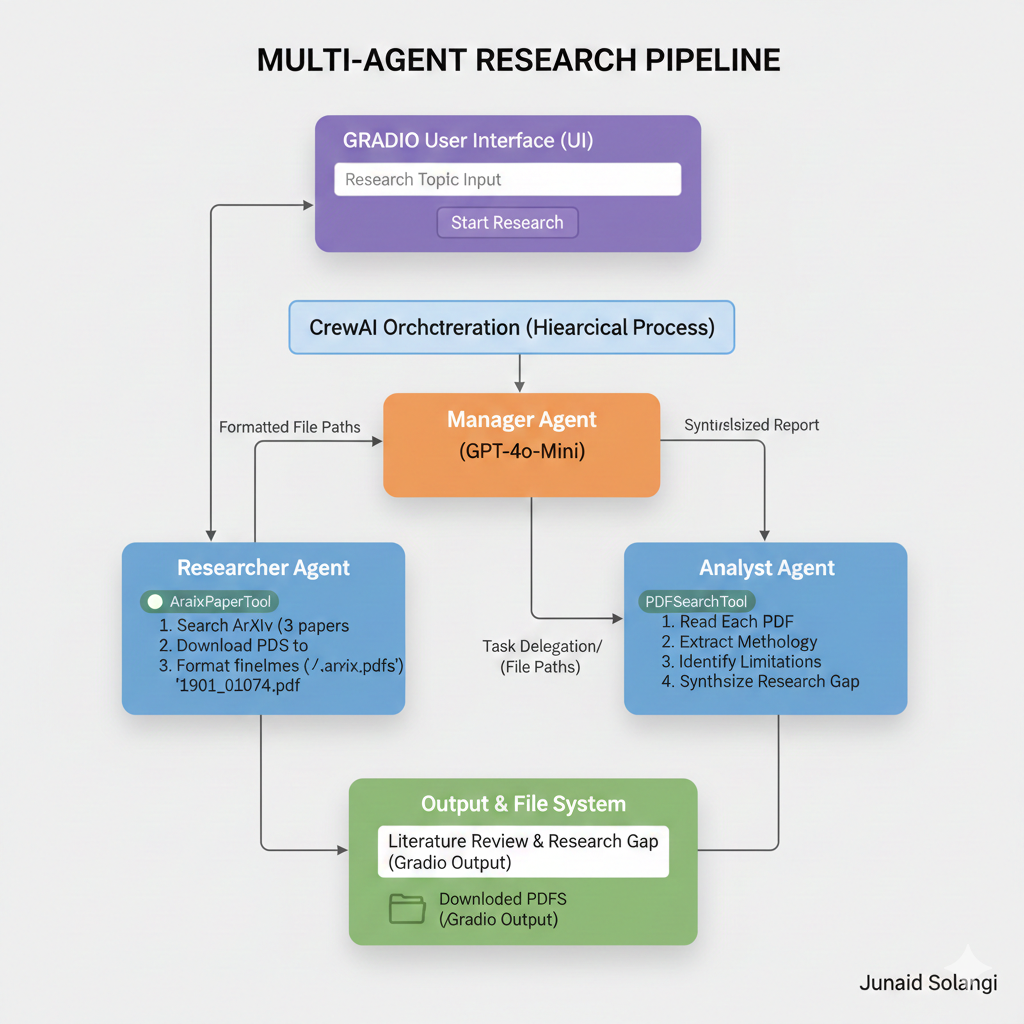

In [ ]:
import gradio as gr
import os
from crewai import Agent, Task, Crew, LLM
from crewai_tools import  ArxivPaperTool , PDFSearchTool
from crewai import Process





# --- 1. CONFIGURATION ---
# os.environ["SERPER_API_KEY"] = "YOUR_SERPER_API_KEY"
# os.environ["GEMINI_API_KEY"] = "YOUR_GEMINI_KEY" # Ensure this is set!
os.environ['OPENAI_API_KEY'] = key  # Replace this with your key\

# Safety: Create directory for file output
if not os.path.exists('./Literature-review-&-Research-Gap'):
    os.makedirs('./Literature-review-&-Research-Gap')

# Initialize the LLM directly through CrewAI
llm = LLM(
    model="gpt-4o-mini",
    temperature=0.2
)

print(f"LLM Initialized: {llm.model}")

pdf_search_tool = PDFSearchTool()
arxiv_tool = ArxivPaperTool(download_pdfs=True,save_dir="./arxiv_pdfs")



# 2. Define Specialist Agents
researcher = Agent(
    role='Research Librarian',
    goal='Search ArXiv and download PDFs. Provide the EXACT save_dir="./arxiv_pdfs".',
    backstory='You are meticulous at file management and technical research.',
    tools=[arxiv_tool],
    verbose=True)


analyst = Agent(
    role='Scientific Analyst',
    goal='Perform RAG search on specific PDF paths(./arxiv_pdfs) to find research gaps.',
    backstory='An expert at extracting deep insights from specific technical documents.',
    tools=[PDFSearchTool()],
    verbose=True
)


# --- 4. EXECUTION FUNCTION ---
def run_crew(topic):
    """
    Takes a topic from the UI, defines new tasks, and runs the crew.
    """
    # Define Tasks dynamically based on user input
    # 4. Define Tasks
    research_task = Task(
      description=f"""
      1. Search ArXiv for 3 papers on the topic: "{topic}" and download them.
      2. Identify the ArXiv IDs (e.g., 1901.01074).
      3. Convert those IDs to the local filename format by replacing '.' with '_'.
        Example: 1901.01074v3.pdf → 1901_01074v3.pdf
      4. Verify the file exists in ./arxiv_pdfs before listing it.
      """,
      expected_output=(
          "A list of exact local filenames such as "
          "./arxiv_pdfs/1901_01074v3.pdf"
      ),
      agent=researcher
  )



    analysis_task = Task(
      description=f"""
      Using the downloaded PDFs related to "{topic}",
      perform a detailed literature review.

      For EACH paper:
      - Title
      - Extract methodology
      - Identify limitations

      Finally, synthesize a clear research gap.
      """,
      expected_output=(
          "A structured literature review followed by a clearly defined research gap."
      ),
      agent=analyst
  )


    manager = Agent(
      role="Research Manager",
      goal="Coordinate agents and ensure tasks flow correctly",
      backstory="Expert in managing research workflows",
      llm=llm,
      verbose=True)

    research_crew = Crew(
        agents=[researcher, analyst],
        tasks=[research_task, analysis_task],
        process=Process.hierarchical,
        manager_agent=manager,
        verbose=True)

    result = research_crew.kickoff()
    # return str(result)
        # 1. Get the raw text string
    output_text = result.raw

    # 2. Remove the "```markdown" wrapper if the LLM added it
    #    (This is what causes the scrollable text box)
    if output_text.startswith("```"):
      output_text = output_text.strip("`").replace("markdown", "").strip()


    return output_text



# --- GRADIO INTERFACE DESIGN ---

import gradio as gr
import os

# --- GRADIO INTERFACE DESIGN ---

def launch_ui():
    # custom_css handles the styling
    custom_css = """
    #header { text-align: center; padding-bottom: 20px; }
    .gradio-container { background-color: #f9fafb; }
    #submit-btn { background: linear-gradient(90deg, #4f46e5, #3b82f6); color: white; border: none; }
    #submit-btn:hover { opacity: 0.9; }
    """


    with gr.Blocks() as demo:
        # Header Section
        with gr.Row(elem_id="header"):
            gr.Markdown("""
                #  AI Research Crew
                **Orchestrating agents to discover, download, and dissect scientific literature.**
                **Developed by Junaid Solangi**
            """)

        with gr.Sidebar():
            gr.Markdown("### ⚙️ Research Configuration")
            topic_input = gr.Textbox(
                label="Topic of Interest",
                placeholder="e.g., Temporal Graph RAG in Medicine",
                lines=2
            )

            with gr.Accordion("Advanced Settings", open=False):
                num_papers = gr.Slider(minimum=1, maximum=5, value=3, step=1, label="Max Papers")
                model_choice = gr.Dropdown(["gpt-4o-mini", "gpt-4o"], value="gpt-4o-mini", label="Manager Model")

            run_btn = gr.Button("🚀 Start Research", variant="primary", elem_id="submit-btn")

            gr.Markdown("---")
            gr.Markdown("### 📁 Output Directory")
            # Fix 2: Changed language from 'bash' to None/standard text to avoid ValueError
            gr.Code(value="./arxiv_pdfs", language=None, interactive=False)

        with gr.Column():
            with gr.Tabs():
                with gr.TabItem("📖 Literature Review"):
                    output_md = gr.Markdown(
                        value="*The final research gap analysis will appear here after the agents finish their work.*"

                    )

                with gr.TabItem("📋 Process Logs"):
                    gr.Markdown("Check your Colab cell output below to see the agents talking in real-time.")
                    log_output = gr.Textbox(
                        label="Status Tracker",
                        placeholder="Waiting for launch...",
                        interactive=False
                    )

        # Logic for the run button
        def wrapped_run(topic):
            if not topic or not topic.strip():
                return "Please enter a valid research topic.", "Idle"

            # This calls your previously defined run_crew function
            result = run_crew(topic)
            return result, "Analysis Complete ✅"

        run_btn.click(
            fn=wrapped_run,
            inputs=[topic_input],
            outputs=[output_md, log_output],
        )

    # Fix 1 cont.: Passing theme and css here for Gradio 6.0 compatibility
    demo.launch(
        share=True,
        debug=True,
        theme=gr.themes.Soft(primary_hue="indigo")

    )

# Run the UI
launch_ui()

LLM Initialized: gpt-4o-mini
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://071a76874fcd92708e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: f549cb7f-15a8-482d-ac93-3432b6c4d31b                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name:                                                                                                          │
│        1. Search ArXiv for 3 papers on the topic: "RAG" and download them.                                      │
│        2. Identify the ArXiv IDs (e.g., 1901.01074).                                                            │
│        3. Convert those IDs to the local filename format by replacing '.' with '_'.                             │
│          Example: 1901.01074v3.pdf → 1901_01074v3.pdf                                                           │
│        4. Verify the file exists in ./arxiv_pdfs before listing it.                                             │
│                                                                                                                 │
│  ID: 65c889e5-b8dc-4fa5-99c7-719e21ba8ae4                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Research Manager                                                                                        │
│                                                                                                                 │
│  Task:                                                                                                          │
│        1. Search ArXiv for 3 papers on the topic: "RAG" and download them.                                      │
│        2. Identify the ArXiv IDs (e.g., 1901.01074).                                                            │
│        3. Convert those IDs to the local filename format by replacing '.' with '_'.                             │
│          Example: 1901.01074v3.pdf → 1901_01074v3.pdf                                                           │
│        4. Verify the file exists in ./arxiv_pdfs before listing it.                                             │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

ERROR:root:OpenAI API call failed: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-or-v1*************************************************************63db. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}
ERROR:root:OpenAI API call failed: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-or-v1*************************************************************63db. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}


...

╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── Execution Traces ────────────────────────────────────────────────╮
│                                                                                                                 │
│  🔍 Detailed execution traces are available!                                                                    │
│                                                                                                                 │
│  View insights including:                                                                                       │
│    • Agent decision-making process                                                                              │
│    • Task execution flow and timing                                                                             │
│    • Tool usage details                                                                                         │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Would you like to view your execution traces? [y/N] (20s timeout): 

ERROR:crewai.events.listeners.tracing.trace_batch_manager:Failed to send events: 404. Response: {"error":"Couldn't find EphemeralTraceBatch with [WHERE \"ephemeral_trace_batches\".\"ephemeral_trace_id\" = $1]","message":"Trace batch not found"}. Events will be lost.


╭─────────────────────────────────────────── 🔍 Local Traces Collected ───────────────────────────────────────────╮
│                                                                                                                 │
│  📊 Your execution traces were collected locally!                                                               │
│                                                                                                                 │
│  Unfortunately, we couldn't upload them to the server right now, but here's what we captured:                   │
│  • 36 trace events                                                                                              │
│  • Execution duration: 647918ms                                                                                 │
│  • Batch ID: c131b517-32b4-4523-b0d8-5f297c80ec76                                                               │
│                                                                                                                 │
│  ✅ Tracing has been enabled for future runs!                                                                   │
│  Your preference has been saved. Future Crew/Flow executions will automatically collect traces.                 │
│  The traces include agent decisions, task execution, and tool usage.                                            │
│                                                                                                                 │
│  To disable tracing later, do any one of these:                                                                 │
│  • Set tracing=False in your Crew/Flow code                                                                     │
│  • Set CREWAI_TRACING_ENABLED=false in your project's .env file                                                 │
│  • Run: crewai traces disable                                                                                   │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

#Literature Review

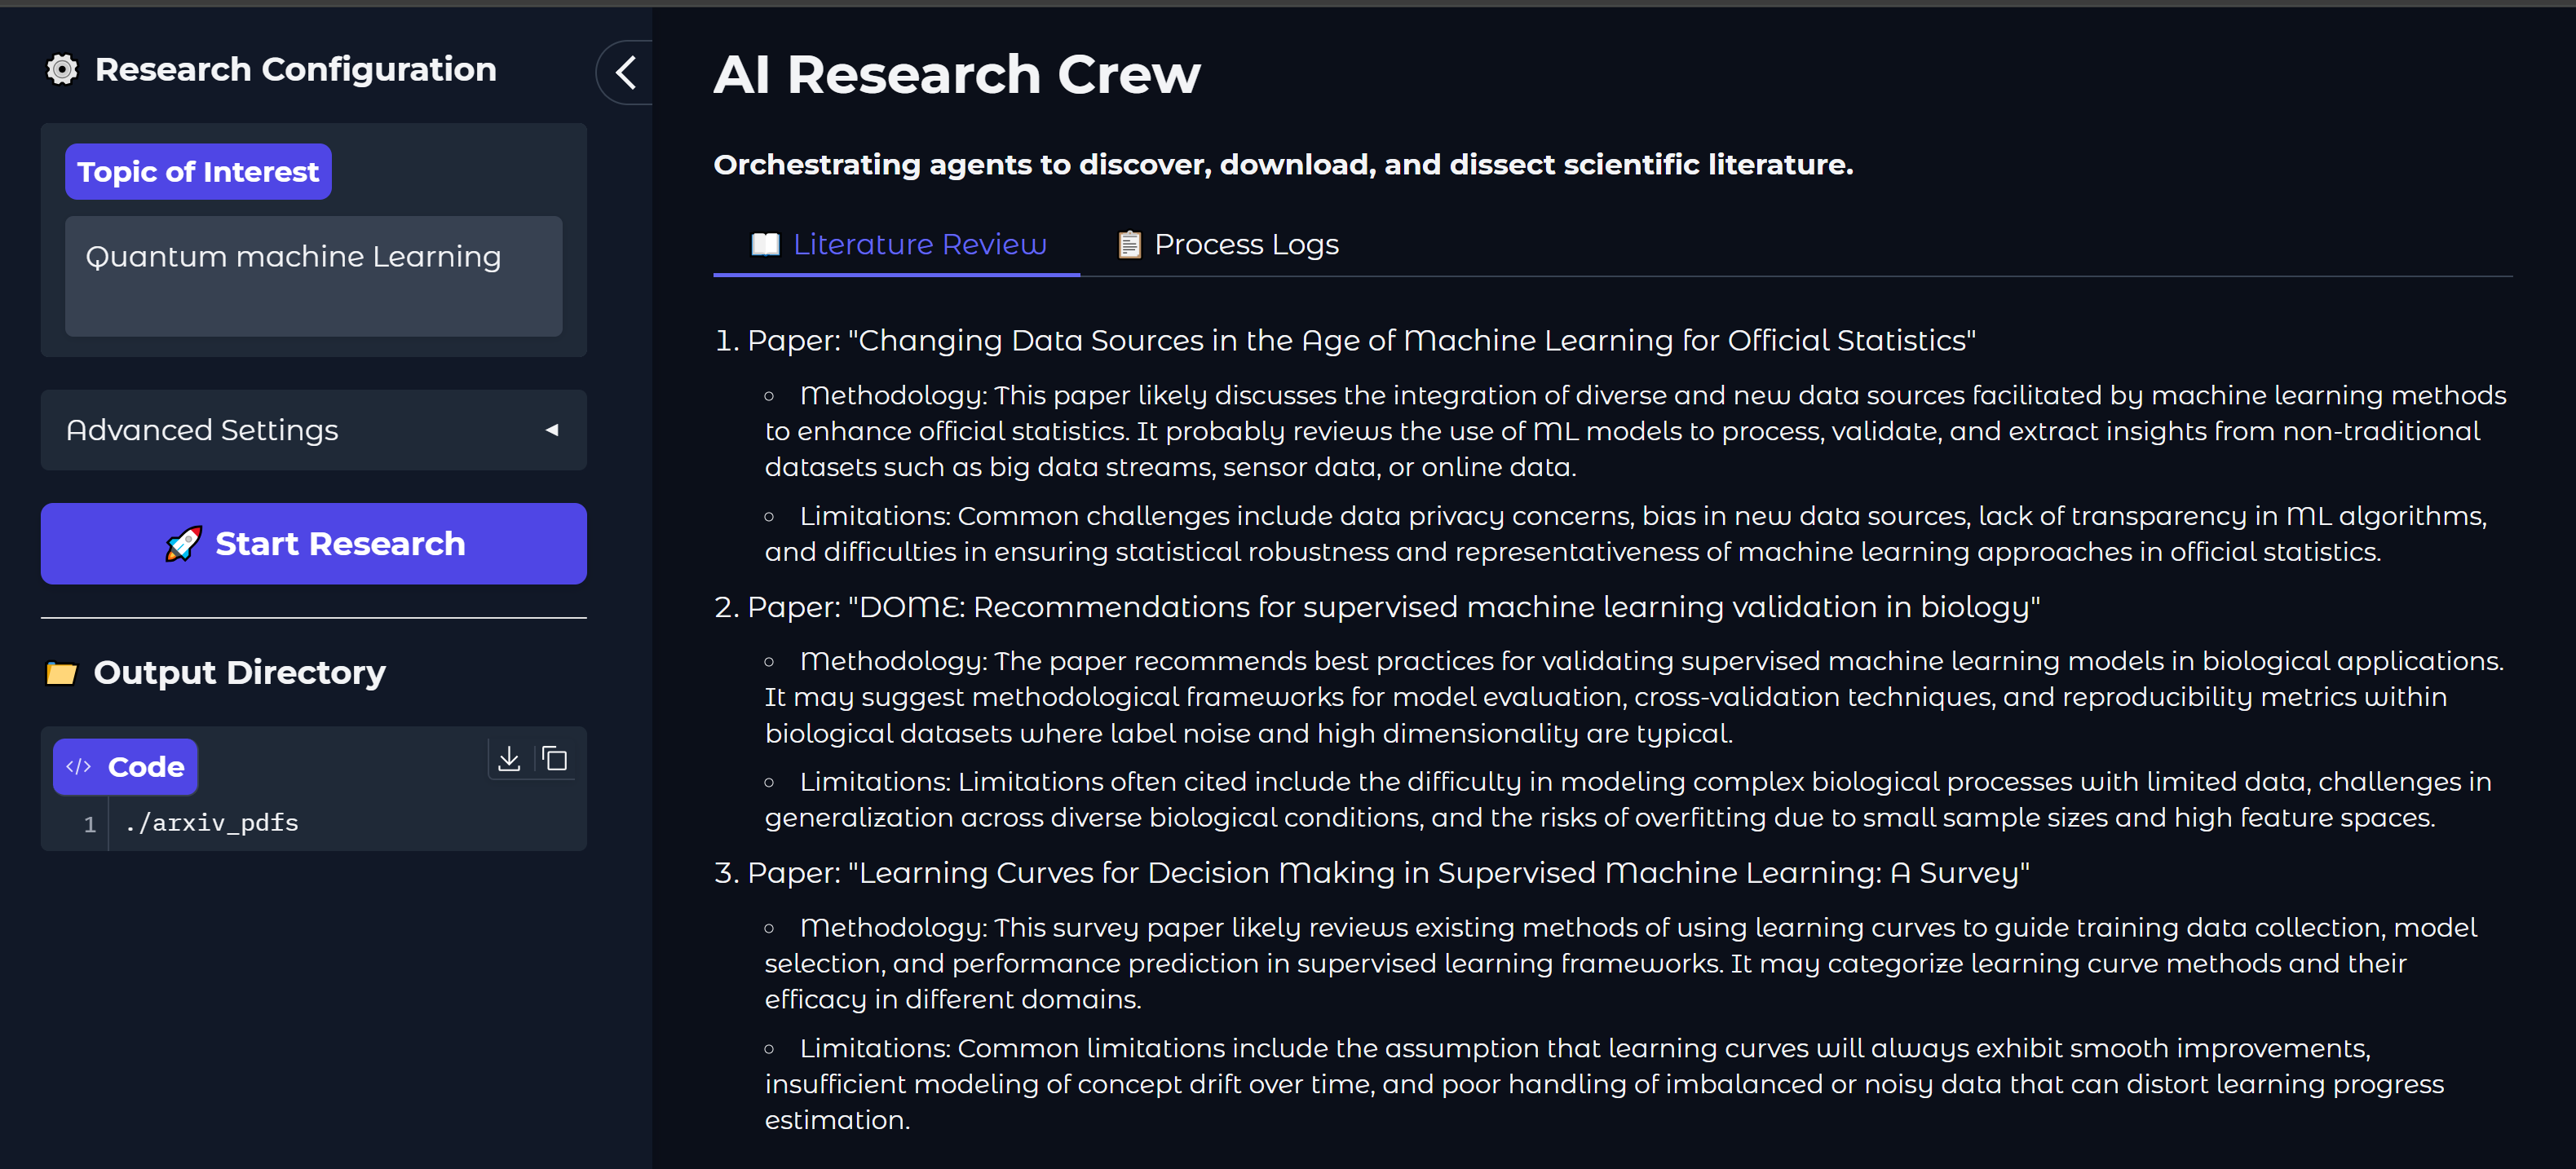

# Research Gap

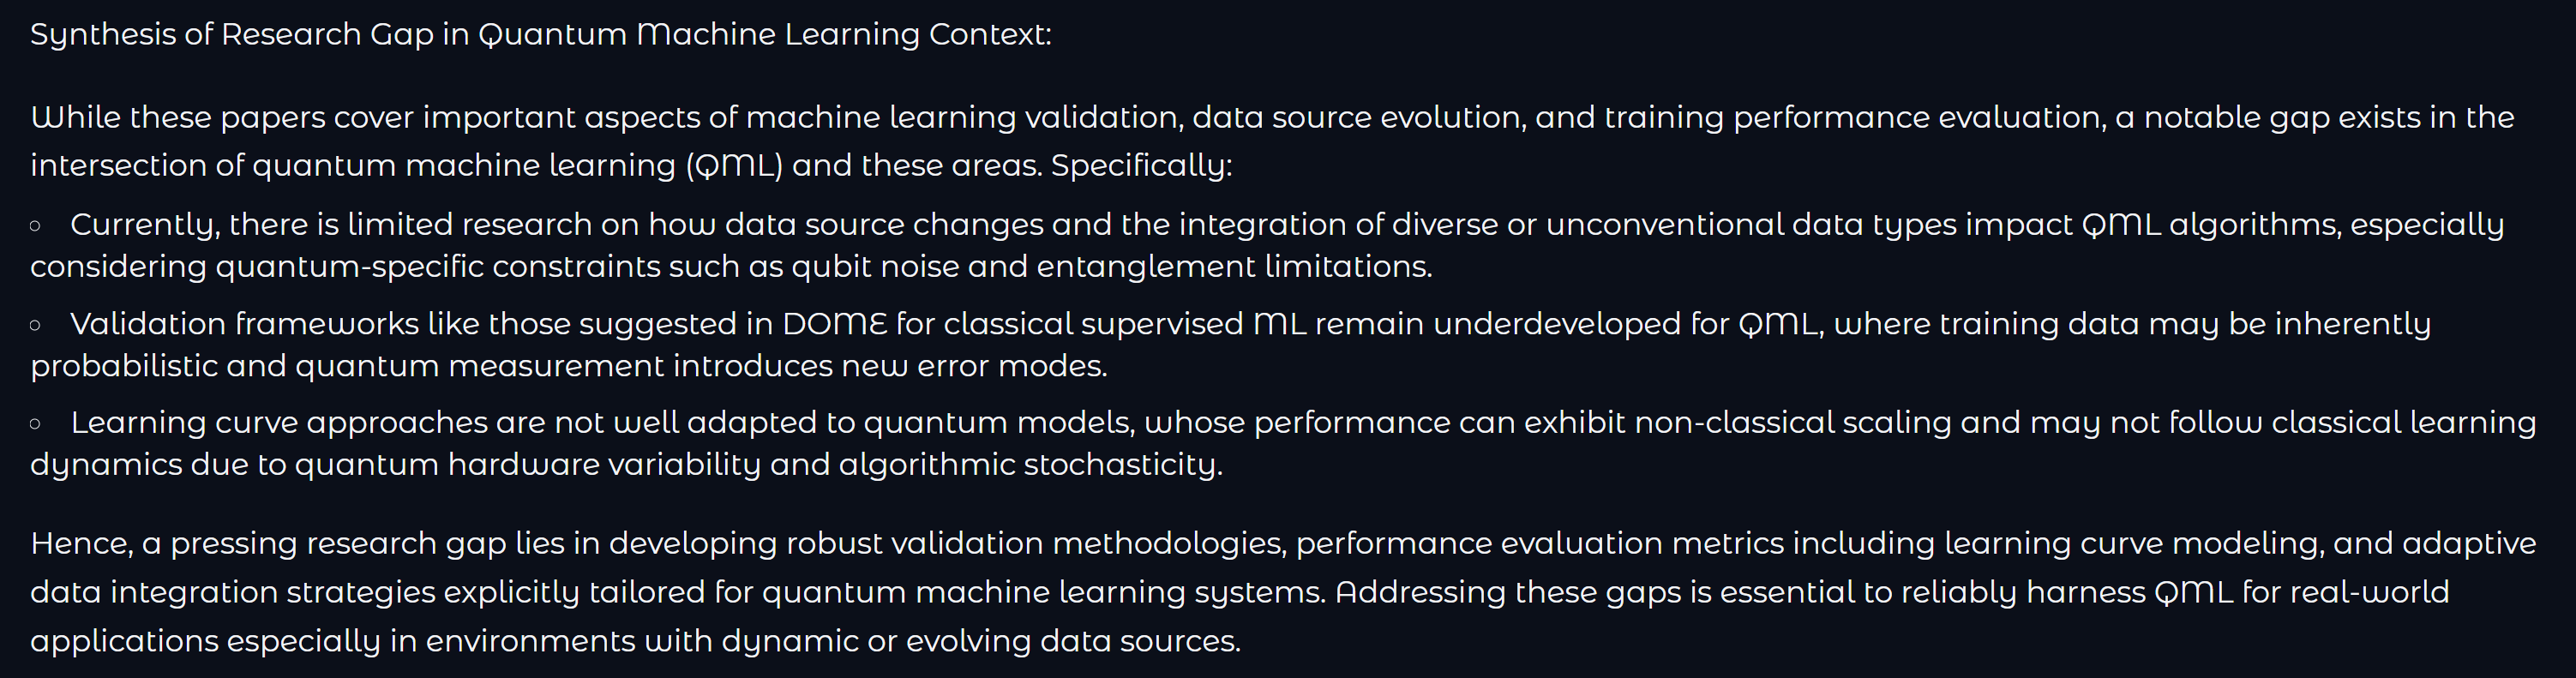